In [ ]:
# Importing the necessary libraries for data manipulation and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **CFPB Dataset Loading, Preprocessing, Feature Engineering and Stratified Sampling**

Objective: Prepare the CFPB complaints data for downstream analysis by engineering time and geography features, reviewing product-level complaint structure, visualizing quarterly Credit Reporting trends, and exporting a trimmed Credit Card subset for EDA and forecasting notebooks.

This notebook focuses on data preparation and exploratory diagnostics, with emphasis on quarterly product-level structure, regional feature engineering, and preparation of a trimmed Credit Card subset for downstream analysis.

This notebook prepares the following artifacts:
- engineered temporal and geographic features (`year_quarter`, `region`, `stratum`) on the raw complaints data
- exploratory product, time, and region diagnostics used to compare major product groups
- quarterly Credit Reporting complaint trend view based on `../data/processed/credit_reporting_monthly_data.csv` (aggregated to quarter)
- final trimmed Credit Card subset exported for potential forecasting workflows

# **1. Project Context**

## 1.1 [...]

[...]

## 1.2 Research Questions

This project seeks to answer the following research questions:

- **RQ1: Do Southern region complaint trajectories exhibit significantly different temporal dynamics (trend, seasonality, volatility) compared to other U.S. regions?**
- **RQ2: Which model family provides the most actionable forecasts for South vs. non-South credit reporting complaints?**
- **RQ3: Will forecasted credit reporting complaints in the South continue rising through 2027, and at what rate relative to other regions?**

## 1.3 Relevance and Practical Implications

The answers to the above have several potential real-life relevance and practical implications; for example:

(i) For CFPB:
- Resource Allocation: CFPB can optimize investigator staffing and regional office budgets
- Staffing Optimization: Monthly/Quarterly forecasts enable the time-granularity needed for budgeting (federal fiscal year planning)
- Regional Equity: South-specific forecasts identify persistent disparity patterns requiring intervention
- Data-Driven Policy: Forecast deviations signal policy effectiveness or emerging crises

(ii) For Financial Institutions:
- Industry Planning: Financial institutions can proactively scale customer service capacity
- Customer Service Capacity Planning: Complaint volume forecasts inform call center staffing, training cycles
- Risk Management: Elevated forecast regions/products trigger proactive compliance reviews
- Regulatory Relations: Anticipating complaint surges enables preemptive CFPB engagement

(iii) For Consumers:
- Transparency: Public forecasts signal expected wait times, complaint processing capacity
- Advocacy: Regional disparities in complaint patterns inform consumer protection advocacy

(iv) For Regulators:
- Policy Evaluation: Regulators can assess intervention effectiveness via deviation from forecasts
- Equity Monitoring: Regional forecasts identify persistent disparity patterns requiring targeted interventions

## 1.4 Limitations

The project at its current state has certain limitations:
1. Causal Interpretation: Forecasts describe what will happen, not why (no causal inference)
   
2. Exogenous Shocks: Models trained on historical data may fail during unprecedented events (e.g., major data breaches, new regulations)
   
3. Product Aggregation: Credit reporting category aggregates diverse sub-issues with heterogeneous dynamics
   
4. State-Level Granularity: Current analysis stops at South vs. Other; state-level models feasible but require larger sample

# **2. Data Description**

## 2.1 Dataset Overview

The [CFPB Consumer Complaint Database](https://www.consumerfinance.gov/data-research/consumer-complaints/) is a public repository of 13.8 million consumer complaints (2011-present, which is end of February 2026 as of the time of this project) across financial products and services, including credit reporting, credit cards, debt collection, mortgages, and banking.

Key elements include complaint date, product and sub-product, issue, company, state, and company response metadata. The database is used to monitor complaint patterns, support consumer transparency, and evaluate response behavior over time.

## 2.2 Dataset Characteristics

- Source: Consumer Financial Protection Bureau (CFPB) Consumer Complaint Database
- Access: Publicly available at https://www.consumerfinance.gov/data-research/consumer-complaints/ 
- Scope: Historical complaints from July 2011 to present (dataset is continuously updated; the date this dataset was pulled for this project was February 24, 2026)
- Dataset Size: Full database contains 13.8 million records of consumer complaints (>4.9 GB) as at the date of this project (February 24, 2026)
- GitHub Repository of this Project: https://github.com/kazishahid-ds/CFPB-complaints-analysis

## 2.3 Exploratory Data Analysis (EDA) #1 (Full Dataset)

This section performs a high-level exploratory review of the full CFPB complaints dataset before any filtering or feature engineering. The goal is to establish the scale, field coverage, temporal span, and dominant complaint categories that shape the downstream analysis.

The EDA below focuses on four questions:

- How large is the raw dataset and what fields are available for analysis?
- Which columns show the most missingness in the full extract?
- Which product categories dominate the complaint mix?
- How has total complaint volume evolved over time, and which submission channels are most common?

In [ ]:
# Loading the full dataset
df = pd.read_csv(r"..\data\complaints.csv")

In [ ]:
# Display the shape and column names of the loaded dataset
print(f"The loaded dataset has {df.shape[0]:,} rows, and {df.shape[1]:,} columns as follows:\n{df.columns.tolist()}")

The loaded dataset has 13,843,560 rows, and 18 columns as follows:
['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']


In [5]:
# Preview core fields from the full dataset
df.head()

,Date received,Product,Sub-product,Issue,Company,State,Submitted via,Company response to consumer,Timely response?
0,2020-07-13,Mortgage,FHA mortgage,Trouble during payment process,"SAMC Honebee TRS, LLC",AL,Web,Closed with explanation,Yes
1,2023-12-16,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,"FactorTrust, Inc.",NY,Web,Closed with explanation,Yes
2,2024-01-27,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",NY,Web,Closed with non-monetary relief,Yes
3,2019-05-22,"Credit reporting, credit repair services, or o...",Credit reporting,Problem with fraud alerts or security freezes,Experian Information Solutions Inc.,CA,Web,Closed with explanation,Yes
4,2023-12-21,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Experian Information Solutions Inc.,FL,Web,Closed with explanation,Yes


In [ ]:
# Ensure Date received is datetime for time-based summaries/plots
if not pd.api.types.is_datetime64_any_dtype(df["Date received"]):
    df["Date received"] = pd.to_datetime(df["Date received"], errors="coerce")

In [ ]:
# Summarize the size, coverage, and cardinality of the raw dataset
dataset_overview = pd.DataFrame(
    {
        "metric": [
            "Rows",
            "Columns",
            "Date coverage start",
            "Date coverage end",
            "Unique products",
            "Unique sub-products",
            "Unique companies",
            "Unique states",
            "In-memory size (GB)",
        ],
        "value": [
            f"{len(df):,}",
            df.shape[1],
            df["Date received"].min().date(),
            df["Date received"].max().date(),
            df["Product"].nunique(dropna=True),
            df["Sub-product"].nunique(dropna=True),
            df["Company"].nunique(dropna=True),
            df["State"].nunique(dropna=True),
            round(df.memory_usage(deep=True).sum() / 1024**3, 2),
        ],
    }
)

print("Key characteristics of the dataset:")
dataset_overview

Key characteristics of the dataset:


,metric,value
0,Rows,"13,843,560"
1,Columns,9
2,Date coverage start,2011-12-01
3,Date coverage end,2026-02-24
4,Unique products,21
5,Unique sub-products,86
6,Unique companies,7833
7,Unique states,63
8,In-memory size (GB),8.09


In [27]:
# Cut off date coverage end to the last full-month data (i.e., month ending 31 January 2026)
cutoff_date_start = pd.to_datetime("2012-01-01")
cutoff_date_end = pd.to_datetime("2025-12-31")
df = df[(df["Date received"] >= cutoff_date_start) & (df["Date received"] <= cutoff_date_end)]

print(f"The dataset's coverage end date is now bounded within {cutoff_date_start.date()} and {cutoff_date_end.date()} to ensure we only analyze complete quarters of data.")

The dataset's coverage end date is now bounded within 2012-01-01 and 2025-12-31 to ensure we only analyze complete quarters of data.


In [ ]:
# Inspect missingness across the full-dataset fields used in this notebook
missingness_summary = (
    df.isna()
      .mean()
      .mul(100)
      .round(2)
      .rename_axis("column")
      .reset_index(name="missing_pct")
      .sort_values(["missing_pct", "column"], ascending=[False, True])
      .reset_index(drop=True)
)

print("Missingness summary for key fields:")
missingness_summary

Missingness summary for key fields:


,column,missing_pct
0,Tags,94.80
1,Consumer disputed?,94.45
2,Consumer complaint narrative,73.06
3,Company public response,47.45
4,Consumer consent provided?,16.17
5,Sub-issue,6.42
6,Sub-product,1.70
7,State,0.43
8,ZIP code,0.22
9,Company,0.00


,product,complaint_count
11,Credit reporting or other personal consumer re...,8648731
10,"Credit reporting, credit repair services, or o...",2163844
9,Debt collection,1013429
8,Mortgage,440724
7,Checking or savings account,344990
6,Credit card,290278
5,Credit card or prepaid card,206368
4,"Money transfer, virtual currency, or money ser...",169517
3,Credit reporting,140429
2,Student loan,121694


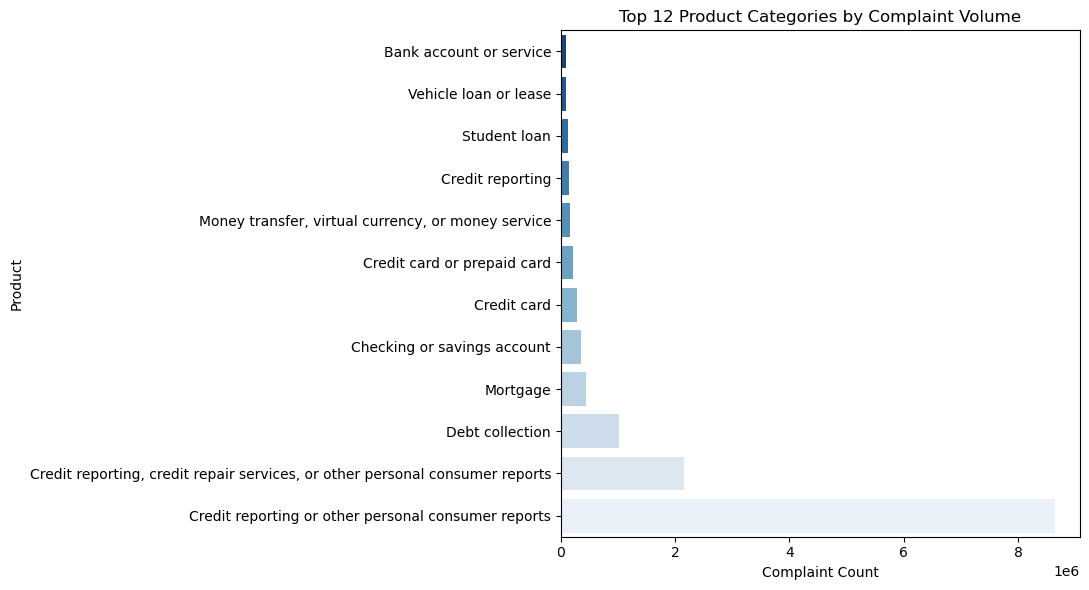

In [8]:
# Visualize the dominant complaint products in the full dataset
product_counts = (
    df["Product"]
      .fillna("Missing")
      .value_counts()
      .head(12)
      .sort_values()
      .rename_axis("product")
      .reset_index(name="complaint_count")
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(
    data=product_counts,
    x="complaint_count",
    y="product",
    palette="Blues_r",
    ax=ax,
    hue="product",
    legend=False,
 )
ax.set_title("Top 12 Product Categories by Complaint Volume")
ax.set_xlabel("Complaint Count")
ax.set_ylabel("Product")
plt.tight_layout()

product_counts.sort_values("complaint_count", ascending=False)

,submitted_via,complaint_count
6,Web,12224714
5,Referral,267517
4,Phone,209507
3,Postal mail,106634
2,Fax,25647
1,Web Referral,1240
0,Email,414


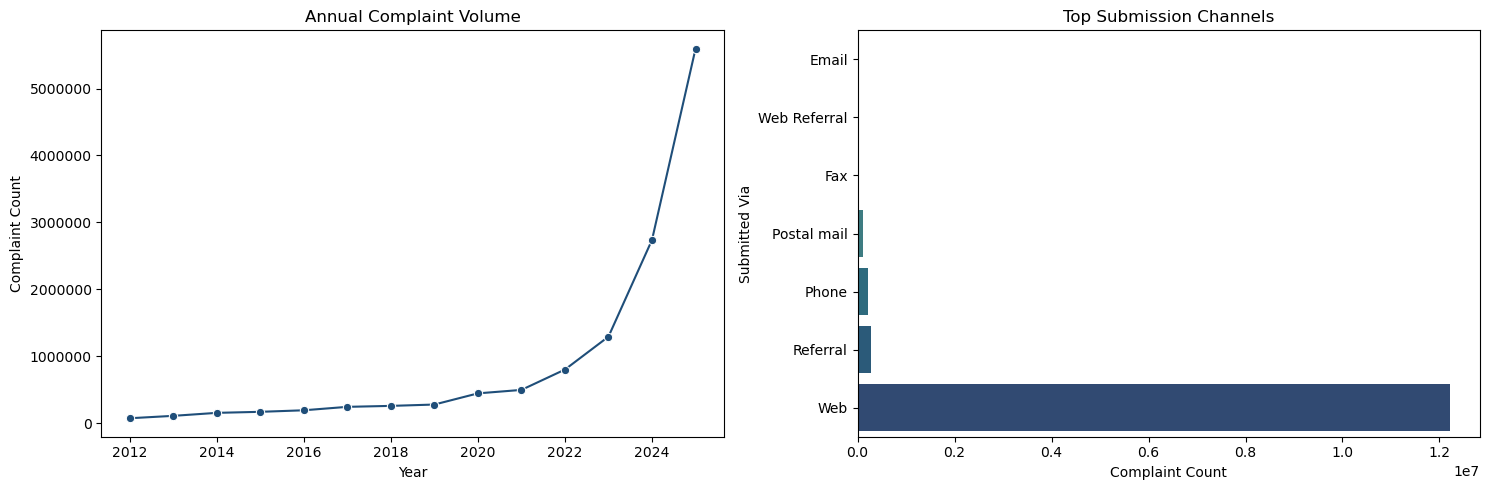

In [28]:
# Plot overall complaint volume through time and summarize submission channels
yearly_counts = (
    df.assign(year=df["Date received"].dt.year)
      .groupby("year")
      .size()
      .reset_index(name="complaint_count")
)

submission_counts = (
    df["Submitted via"]
      .fillna("Missing")
      .value_counts()
      .head(8)
      .sort_values()
      .rename_axis("submitted_via")
      .reset_index(name="complaint_count")
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(
    data=yearly_counts,
    x="year",
    y="complaint_count",
    marker="o",
    color="#1f4e79",
    ax=axes[0],
)
axes[0].set_title("Annual Complaint Volume")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Complaint Count")
axes[0].ticklabel_format(style="plain", axis="y")

sns.barplot(
    data=submission_counts,
    x="complaint_count",
    y="submitted_via",
    palette="crest",
    ax=axes[1],
    hue="submitted_via",
    legend=False,
 )
axes[1].set_title("Top Submission Channels")
axes[1].set_xlabel("Complaint Count")
axes[1].set_ylabel("Submitted Via")

plt.tight_layout()

submission_counts.sort_values("complaint_count", ascending=False)

# **3. Data Preprocessing**

## 3.1 Create Year-Quarter

In [10]:
df['Date received'] = pd.to_datetime(df['Date received'], errors='coerce')

df['year_quarter'] = (
    df['Date received']
      .dt.to_period('Q')
      .astype(str)
)

This transformation produces quarterly labels such as `2021Q1`, `2022Q3`, etc.

## 3.2 Map State to Region

The workflow uses U.S. Census-style regional groupings rather than individual states. This reduces sparsity while preserving interpretable geographic structure for downstream analysis.

**1. Northeast**
- CT, ME, MA, NH, RI, VT
- NJ, NY, PA

**2. Midwest**
- IL, IN, MI, OH, WI
- IA, KS, MN, MO, NE, ND, SD

**3. South**
- DE, FL, GA, MD, NC, SC, VA, DC, WV
- AL, KY, MS, TN
- AR, LA, OK, TX

**4. West**
- AZ, CO, ID, MT, NV, NM, UT, WY
- AK, CA, HI, OR, WA

**5. Other**
- Remaining values in `State` (for example territories or non-state codes)

In [12]:
northeast = ['CT','ME','MA','NH','RI','VT','NJ','NY','PA']
midwest   = ['IL','IN','MI','OH','WI','IA','KS','MN','MO','NE','ND','SD']
south     = ['DE','FL','GA','MD','NC','SC','VA','DC','WV',
             'AL','KY','MS','TN','AR','LA','OK','TX']
west      = ['AZ','CO','ID','MT','NV','NM','UT','WY','AK','CA','HI','OR','WA']

def map_region(state):
    if state in northeast:
        return 'Northeast'
    elif state in midwest:
        return 'Midwest'
    elif state in south:
        return 'South'
    elif state in west:
        return 'West'
    else:
        return 'Other'

df['region'] = df['State'].apply(map_region)

If needed, rows with unresolved geography can be removed so each record maps cleanly to a regional stratum.

In [ ]:
# Drop rows without valid region
df = df.dropna(subset=['region'])

Regional share is reviewed here to confirm that the aggregated geography feature is coherent and suitable for proportional sampling.

In [27]:
df['region'].value_counts(normalize=True)

region
South        0.540400
West         0.161662
Northeast    0.158621
Midwest      0.130691
Other        0.008627
Name: proportion, dtype: float64

## Step 4: Finalize Geography Feature

The `region` field is retained as the primary geography feature because it is interpretable, stable over time, and suitable for product-time-region stratification.

In [28]:
df['year_quarter'] = pd.to_datetime(df['Date received']).dt.to_period('Q').astype(str)

df['stratum'] = (
    df['Product'].astype(str) + "|" +
    df['year_quarter'].astype(str) + "|" +
    df['region'].astype(str)
)

## Step 5: Check Stratum Granularity

A quick cardinality check confirms that product-time-region strata remain informative without becoming too sparse for exploratory diagnostics and downstream subset design.

In [29]:
num_unique_strata = df['stratum'].nunique()
print(f"Total number of unique strata: {num_unique_strata:,}")

Total number of unique strata: 2,752


In [30]:
strata_counts = df.groupby(['Product', 'year_quarter', 'region']).size()

strata_counts.describe()

count      2752.000000
mean       5030.363372
std       35783.133537
min           1.000000
25%         142.750000
50%         539.000000
75%        1692.250000
max      917786.000000
dtype: float64

Interpretation:
- The median stratum size is large enough to preserve meaningful product-time-region structure.
- The distribution remains right-skewed, which is expected in CFPB data because complaint activity is concentrated in a subset of product-time-region combinations.
- A limited long tail of small strata is acceptable for descriptive diagnostics, especially since the downstream workflow ultimately narrows to the credit card subset.

In [31]:
print(f"Number of strata with fewer than 20 samples: {(strata_counts < 20).sum():,} out of {num_unique_strata:,} (i.e., {((strata_counts < 20).sum()/num_unique_strata):.1}%).")

Number of strata with fewer than 20 samples: 194 out of 2,752 (i.e., 0.07%).


Conclusion: the product-time-region structure is sufficiently coherent for feature engineering and downstream subset design.

## Product-Level Complaint Review

This section uses the full complaint dataset to examine product-level volume dynamics before constructing the modeling subset.

In [32]:
# Generate total number of complaints for each quarter
quarterly_complaints = df.groupby('year_quarter').size().reset_index(name='num_complaints')
quarterly_complaints

,year_quarter,num_complaints
0,2011Q4,2536
1,2012Q1,12969
2,2012Q2,21160
3,2012Q3,19125
4,2012Q4,19118
5,2013Q1,26874
6,2013Q2,24837
7,2013Q3,28471
8,2013Q4,28033
9,2014Q1,39607


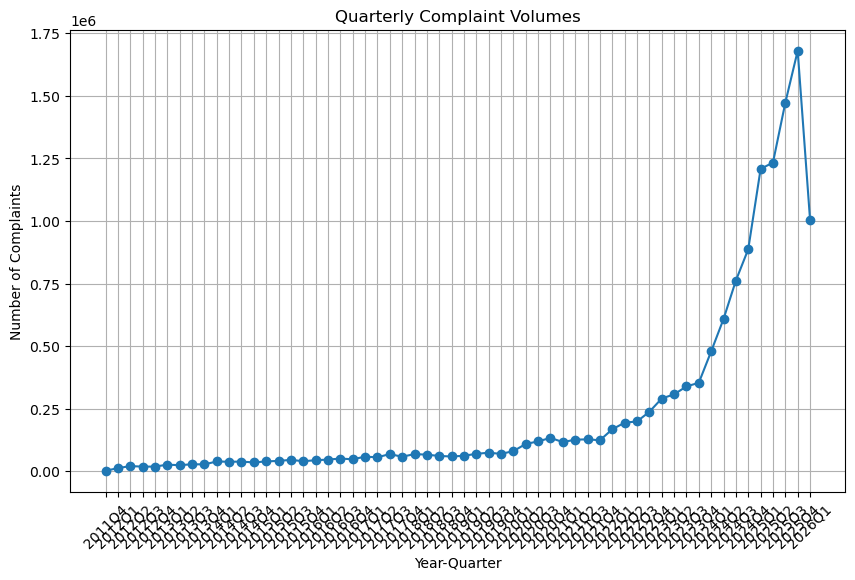

In [33]:
# Plot the quarterly complaint volumes
plt.figure(figsize=(10, 6))
plt.plot(quarterly_complaints['year_quarter'], quarterly_complaints['num_complaints'], marker='o')
plt.title('Quarterly Complaint Volumes')
plt.xlabel('Year-Quarter')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [34]:
# Plot the distribution of complaints by product per quarter
product_counts_qtr = df.groupby(['year_quarter', 'Product']).size().reset_index(name='num_complaints')

In [35]:
# Tabulate the complaint counts by product and quarter (year_quarter in col. 1, and then each product takes a column each)
product_counts_pivot = product_counts_qtr.pivot(index='year_quarter', columns='Product', values='num_complaints').fillna(0)
product_counts_pivot

Product,Bank account or service,Checking or savings account,Consumer Loan,Credit card,Credit card or prepaid card,Credit reporting,Credit reporting or other personal consumer reports,"Credit reporting, credit repair services, or other personal consumer reports",Debt collection,Debt or credit management,...,Money transfers,Mortgage,Other financial service,Payday loan,"Payday loan, title loan, or personal loan","Payday loan, title loan, personal loan, or advance loan",Prepaid card,Student loan,Vehicle loan or lease,Virtual currency
year_quarter,,,,,,,,,,,,,,,,,,,,,
2011Q4,0.0,0.0,0.0,1260.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1276.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2012Q1,1191.0,0.0,141.0,3757.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,7356.0,0.0,0.0,0.0,0.0,0.0,524.0,0.0,0.0
2012Q2,4318.0,0.0,650.0,4340.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,10860.0,0.0,0.0,0.0,0.0,0.0,992.0,0.0,0.0
2012Q3,3643.0,0.0,591.0,3780.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,10465.0,0.0,0.0,0.0,0.0,0.0,646.0,0.0,0.0
2012Q4,3060.0,0.0,604.0,3476.0,0.0,1873.0,0.0,0.0,0.0,0.0,...,0.0,9427.0,0.0,0.0,0.0,0.0,0.0,678.0,0.0,0.0
2013Q1,3532.0,0.0,698.0,3584.0,0.0,3074.0,0.0,0.0,0.0,0.0,...,0.0,15247.0,0.0,0.0,0.0,0.0,0.0,739.0,0.0,0.0
2013Q2,3077.0,0.0,771.0,3310.0,0.0,3470.0,0.0,0.0,0.0,0.0,...,128.0,13459.0,0.0,0.0,0.0,0.0,0.0,622.0,0.0,0.0
2013Q3,3428.0,0.0,815.0,3197.0,0.0,3949.0,0.0,0.0,4397.0,0.0,...,167.0,11756.0,0.0,0.0,0.0,0.0,0.0,762.0,0.0,0.0
2013Q4,3351.0,0.0,833.0,3014.0,0.0,3887.0,0.0,0.0,6672.0,0.0,...,264.0,8936.0,0.0,194.0,0.0,0.0,0.0,882.0,0.0,0.0


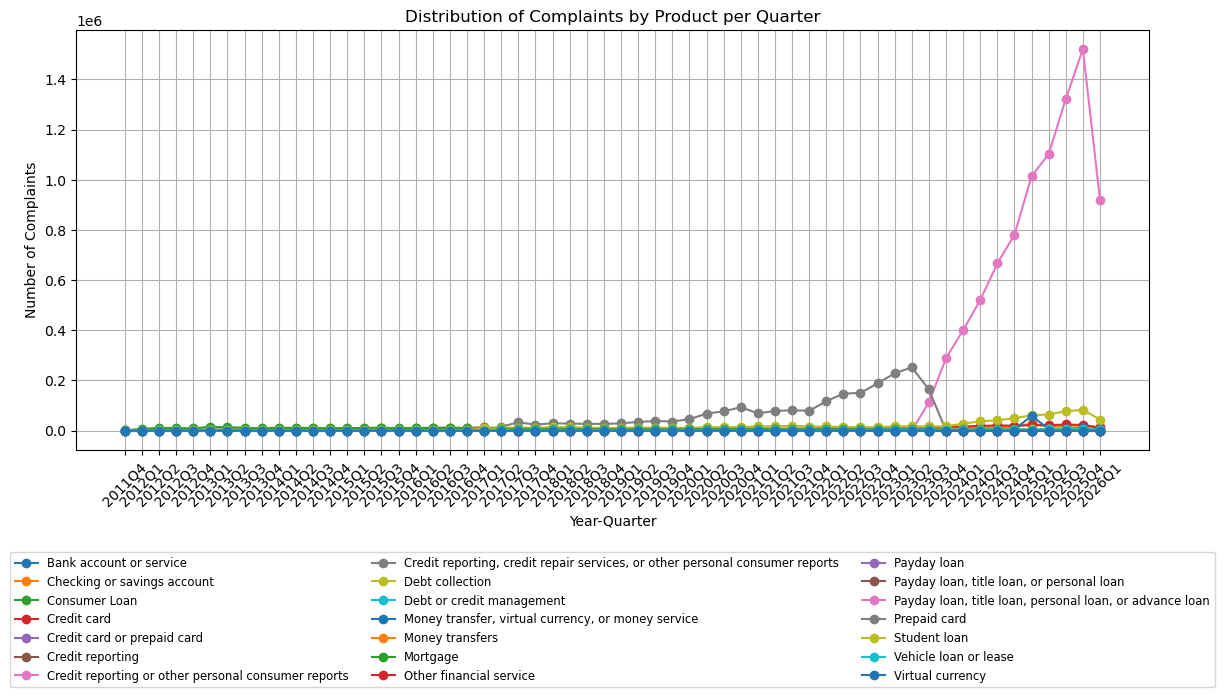

In [36]:
# Plot a line chart for each product's complaint volume over time
plot_df = product_counts_qtr.copy()
plot_df['year_q_period'] = pd.PeriodIndex(plot_df['year_quarter'], freq='Q')

# Build one globally ordered quarter axis shared by all product series
plot_pivot = (
    plot_df.pivot_table(
        index='year_q_period',
        columns='Product',
        values='num_complaints',
        aggfunc='sum'
    )
    .fillna(0)
    .sort_index()
 )

x_labels = plot_pivot.index.astype(str)

plt.figure(figsize=(13, 7))
for product in plot_pivot.columns:
    plt.plot(x_labels, plot_pivot[product].values, marker='o', label=product)

plt.title('Distribution of Complaints by Product per Quarter')
plt.xlabel('Year-Quarter')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45)
plt.grid(True)
# Place legend below chart and spread across columns
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.23), ncol=3, fontsize='small', frameon=True)
plt.tight_layout()
plt.subplots_adjust(bottom=0.35)
plt.show()

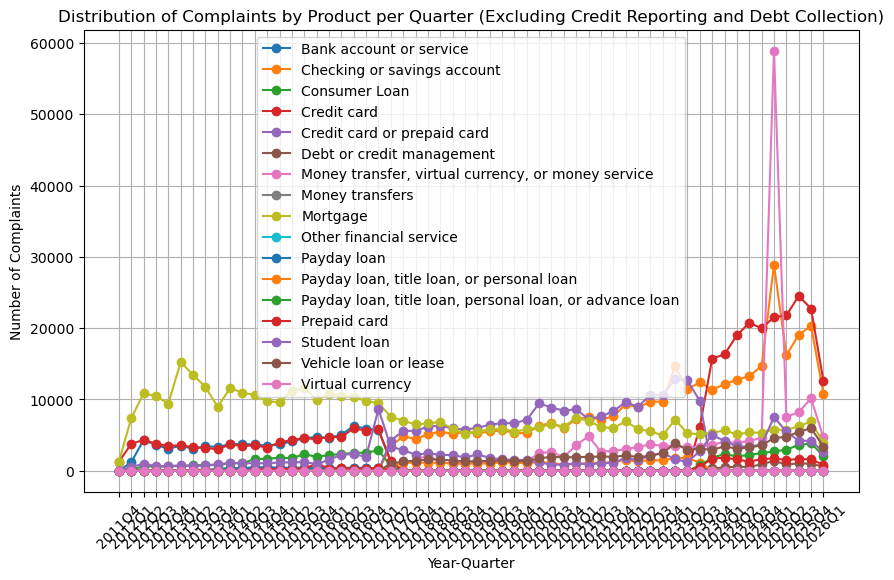

In [37]:
# Plotting the same chart but without the 3 categories starting with "credit reporting" and debt collection, as they are very dominant and make it hard to see the trends in the other products
plt.figure(figsize=(10, 6))
for product in plot_pivot.columns:
    if not product.lower().startswith('credit reporting') and not product.lower().startswith('debt collection'):
        plt.plot(x_labels, plot_pivot[product].values, marker='o', label=product)

plt.title('Distribution of Complaints by Product per Quarter (Excluding Credit Reporting and Debt Collection)')
plt.xlabel('Year-Quarter')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

## Product Type: Credit Reporting

This section uses the pre-aggregated monthly file `../data/processed/credit_reporting_monthly_data.csv`, converts it to quarter buckets (`2011Q4`, `2012Q1`, ...), and plots quarterly `credit_reporting_complaint_count` over time.

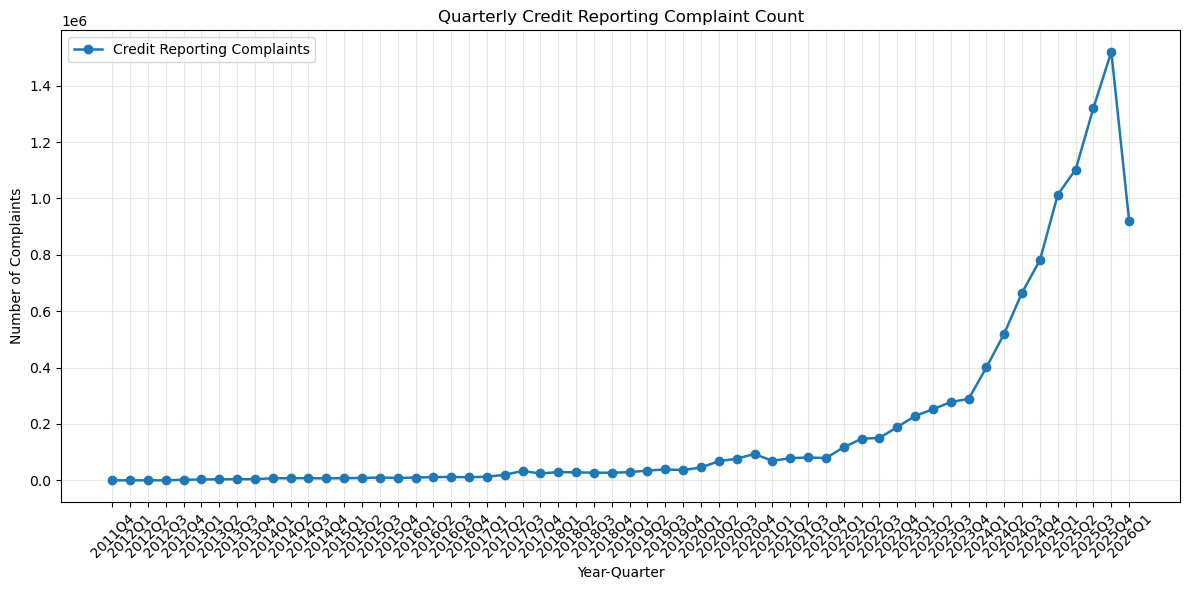

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load monthly credit reporting data and aggregate complaint counts to quarter level
credit_reporting_df = pd.read_csv("../data/processed/credit_reporting_monthly_data.csv")
credit_reporting_df["month"] = pd.to_datetime(credit_reporting_df["month"], format="%Y-%m")
credit_reporting_df = credit_reporting_df.sort_values("month")
credit_reporting_df["year_quarter"] = credit_reporting_df["month"].dt.to_period("Q")

quarterly_credit_reporting = (
    credit_reporting_df
    .groupby("year_quarter", as_index=False)["credit_reporting_complaint_count"]
    .sum()
 )
quarterly_credit_reporting["year_quarter_label"] = quarterly_credit_reporting["year_quarter"].astype(str)

plt.figure(figsize=(12, 6))
plt.plot(
    quarterly_credit_reporting["year_quarter_label"],
    quarterly_credit_reporting["credit_reporting_complaint_count"],
    marker="o",
    linewidth=1.8,
    label="Credit Reporting Complaints"
 )
plt.title("Quarterly Credit Reporting Complaint Count")
plt.xlabel("Year-Quarter")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Product Type: Credit Card

After reviewing Credit Reporting at the quarterly level, the analysis returns to Credit Card diagnostics and subset construction for the downstream modeling track.

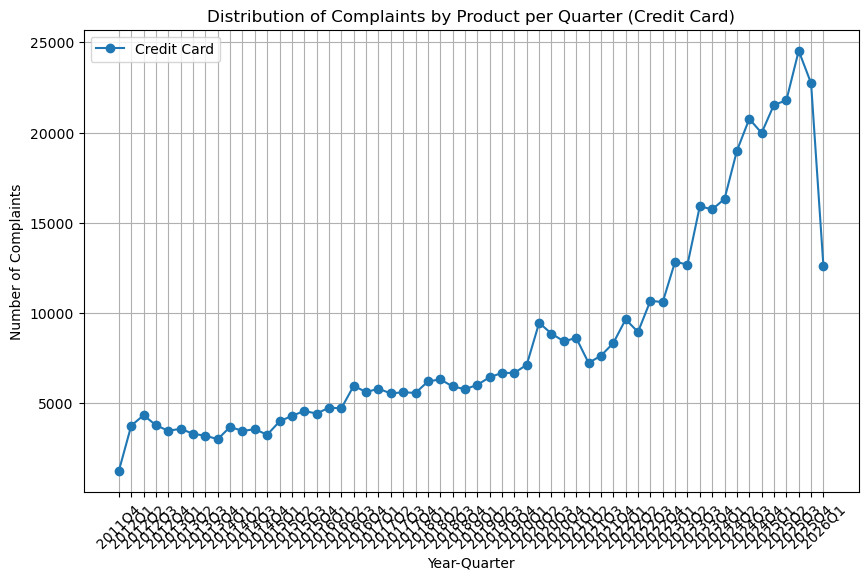

In [38]:
# Plot the same chart but only for the 2 categories starting with "credit card", combined to form one line
plt.figure(figsize=(10, 6))
credit_card_values = plot_pivot[[col for col in plot_pivot.columns if col.lower().startswith('credit card')]].sum(axis=1)
plt.plot(x_labels, credit_card_values, marker='o', label='Credit Card')

plt.title('Distribution of Complaints by Product per Quarter (Credit Card)')
plt.xlabel('Year-Quarter')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

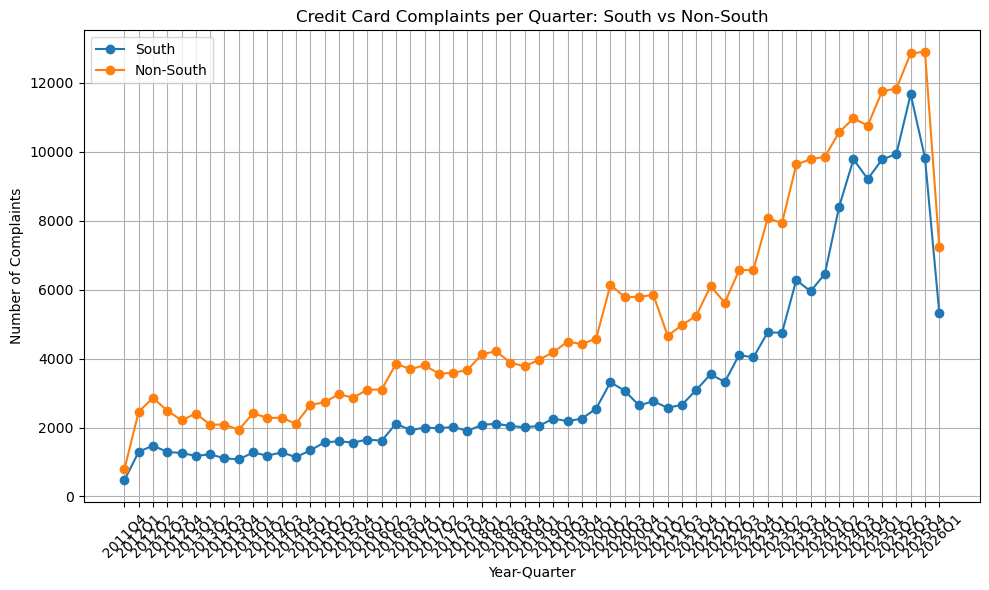

In [41]:
# Plot the above (i.e., for the 2 categories starting with "credit card", combined values) but form two lines: df['region'] == "south" region and everything else (non-South regions)
plt.figure(figsize=(10, 6))

credit_card_cols = [col for col in df['Product'].unique() if col.lower().startswith('credit card')]

for region_label in ['South', 'Non-South']:
    if region_label == 'South':
        region_df = df[df['region'] == 'South']
    else:
        region_df = df[df['region'] != 'South']

    region_counts = (
        region_df[region_df['Product'].isin(credit_card_cols)]
        .groupby('year_quarter')
        .size()
        .reset_index(name='num_complaints')
    )
    region_counts['year_q_period'] = pd.PeriodIndex(region_counts['year_quarter'], freq='Q')
    region_counts = region_counts.set_index('year_q_period').reindex(plot_pivot.index, fill_value=0)

    plt.plot(x_labels, region_counts['num_complaints'].values, marker='o', label=region_label)

plt.title('Credit Card Complaints per Quarter: South vs Non-South')
plt.xlabel('Year-Quarter')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Credit Card Subset Construction

The notebook includes a quarterly Credit Reporting trend check for context, but the exported modeling subset remains records whose `Product` starts with `Credit card`, trimmed to the analysis window used in downstream notebooks.

In [ ]:
# Isolate complaints whose product label starts with "credit card"
df_creditcard = df[df['Product'].str.lower().str.startswith('credit card')]
df_creditcard['Product'].value_counts()

Product
Credit card                    290278
Credit card or prepaid card    206368
Name: count, dtype: int64

In [43]:
df_creditcard

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,...,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,year_quarter,geo,region,stratum
16,2020-03-09,Credit card or prepaid card,General-purpose credit card or charge card,Fees or interest,Problem with fees,On XX/XX/2020 I booked a hotel in XXXX that re...,NaN,JPMORGAN CHASE & CO.,CT,06854,...,Web,2020-03-09,Closed with explanation,Yes,NaN,3559709,2020Q1,CT,Northeast,Credit card or prepaid card|2020Q1|Northeast
29,2020-03-18,Credit card or prepaid card,General-purpose credit card or charge card,Fees or interest,Problem with fees,I have had a Barclays/Uber credit card for nea...,Company has responded to the consumer and the ...,BARCLAYS BANK DELAWARE,CA,94596,...,Web,2020-03-18,Closed with explanation,Yes,NaN,3571498,2020Q1,CA,West,Credit card or prepaid card|2020Q1|West
114,2023-12-15,Credit card,General-purpose credit card or charge card,Problem with a company's investigation into an...,Was not notified of investigation status or re...,Take a look at the attached documents. I reque...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",IL,60160,...,Web,2023-12-15,Closed with non-monetary relief,Yes,NaN,8008970,2023Q4,IL,Midwest,Credit card|2023Q4|Midwest
141,2020-01-04,Credit card or prepaid card,Government benefit card,Trouble using the card,Trouble getting information about the card,I received my new card for my child support an...,Company has responded to the consumer and the ...,"BANK OF AMERICA, NATIONAL ASSOCIATION",AZ,85379,...,Web,2020-01-04,Closed with explanation,Yes,NaN,3485072,2020Q1,AZ,West,Credit card or prepaid card|2020Q1|West
142,2019-07-31,Credit card or prepaid card,General-purpose credit card or charge card,Fees or interest,Problem with fees,NaN,Company has responded to the consumer and the ...,"CITIBANK, N.A.",NaN,XXXXX,...,Web,2019-08-01,Closed with explanation,Yes,NaN,3324741,2019Q3,NaN,Other,Credit card or prepaid card|2019Q3|Other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13843530,2013-11-02,Credit card,NaN,Other fee,NaN,NaN,NaN,WELLS FARGO & COMPANY,NV,89410,...,Web,2013-11-02,Closed with monetary relief,Yes,No,582526,2013Q4,NV,West,Credit card|2013Q4|West
13843536,2013-04-04,Credit card,NaN,Credit reporting,NaN,NaN,NaN,SYNCHRONY FINANCIAL,CA,92591,...,Web,2013-04-05,Closed with explanation,Yes,No,373788,2013Q2,CA,West,Credit card|2013Q2|West
13843547,2013-06-21,Credit card,NaN,Payoff process,NaN,NaN,NaN,"CITIBANK, N.A.",NH,03246,...,Referral,2013-06-24,Closed with explanation,Yes,No,438905,2013Q2,NH,Northeast,Credit card|2013Q2|Northeast
13843548,2023-06-30,Credit card or prepaid card,General-purpose credit card or charge card,"Other features, terms, or problems",Other problem,NaN,NaN,"CITIZENS FINANCIAL GROUP, INC.",PA,15235,...,Phone,2023-06-30,Closed with explanation,Yes,NaN,7190644,2023Q2,PA,Northeast,Credit card or prepaid card|2023Q2|Northeast


In [11]:
# Dates range for the credit card subset
print(f"Dates range from {min(df_creditcard['Date received'])} to {max(df_creditcard['Date received'])}")

Dates range from 2011-12-01 00:00:00 to 2026-02-24 00:00:00


In [ ]:
# Restrict the credit card subset to the working analysis window
df_creditcard = df_creditcard[
    (df_creditcard['Date received'] >= '2012-01-01') &
    (df_creditcard['Date received'] <= '2025-12-31')
]

In [13]:
# Dates range for the credit card subset
print(f"Dates range from {min(df_creditcard['Date received'])} to {max(df_creditcard['Date received'])}")

Dates range from 2012-01-01 00:00:00 to 2025-12-31 00:00:00


# Conclusion

This notebook establishes the data-preparation pipeline for downstream CFPB analysis with two outputs: contextual product diagnostics and a modeling-ready Credit Card subset.

- Time and region features are engineered on the raw CFPB complaints data so the same structure can be reused across downstream notebooks.
- Product-level diagnostics include a quarterly Credit Reporting complaint-count view built from the processed monthly aggregate file.
- The exported artifact is a trimmed Credit Card subset, bounded to `2012-01-01` through `2025-12-31`, ready for notebook 02 EDA and notebook 03 forecasting workflows.